In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [30]:
problem_name = "convergence"
base_problem_name = "Portapilas-2x2-AA_0"
log_file = problem_name + "_log.csv"

data = pd.read_csv(log_file,sep=",")


#TODO: data has only problem_name starting with base_problem_name
data = data[data['problem_name'].str.startswith(base_problem_name)]

#strip whiet spaces from column names and all column values
data.columns = data.columns.str.strip()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].str.strip()

data['n_vertices'] = data['n_vertices'].astype(int)
data['num_non_zeros'] = data['num_non_zeros'].astype(int)
data['max_e_length'] = data['max_e_length'].astype(float)
data['l2_res_norm'] = data['l2_res_norm'].astype(float)
data['transfer_time_us'] = data['t_trans(us)'].astype(float)
data['solve_time_us'] = data['t_solve(us)'].astype(float)
data['assemble_time_us'] = data['t_assem(us)'].astype(float)


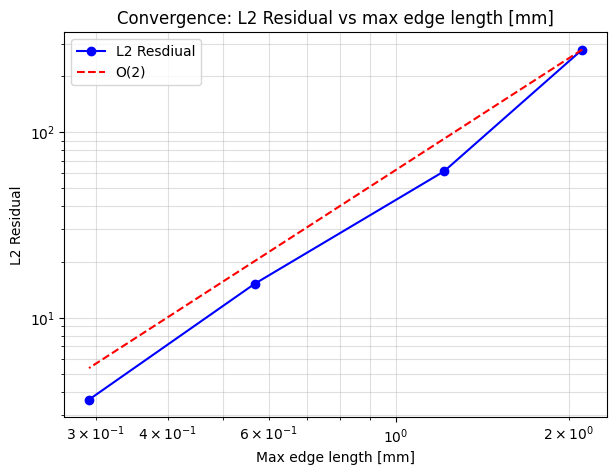

In [31]:
error_arr = data['l2_res_norm'].values
e_length_arr = data['max_e_length'].values

plt.figure(figsize=(7, 5))
plt.loglog(e_length_arr, error_arr, 'bo-', label='L2 Resdiual')

ref_line_max = [error_arr[0] * (v / e_length_arr[0])**(2) for v in e_length_arr]
plt.loglog(e_length_arr, ref_line_max, 'r--', label='O(2)')

plt.xlabel('Max edge length [mm]')
plt.ylabel('L2 Residual')
plt.title('Convergence: L2 Residual vs max edge length [mm]')
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()
plt.show()

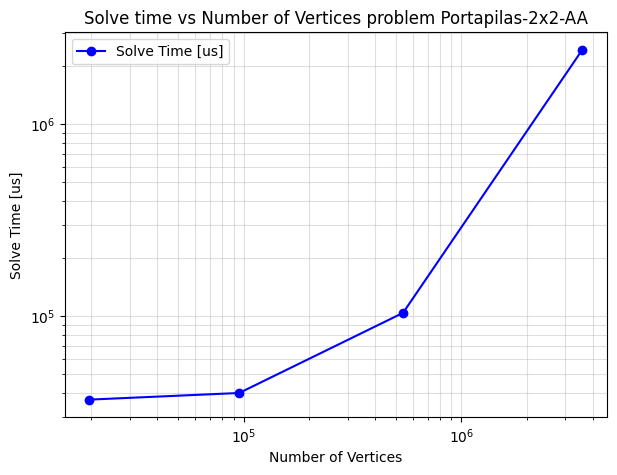

In [35]:
runtime_arr = data['solve_time_us'].values
n_vertices_arr = data['n_vertices'].values

plt.figure(figsize=(7, 5))
plt.loglog(n_vertices_arr, runtime_arr, 'bo-', label='Solve Time [us]')
#plt.loglog(n_vertices_arr, tran_time, 'go-', label='Data Transfer Time [us]')
#ref_line_max = [tran_time[0] * (v / n_vertices_arr[0])**(1) for v in n_vertices_arr]
#plt.loglog(n_vertices_arr, ref_line_max, 'r--', label='O(1)')

plt.xlabel('Number of Vertices')
plt.ylabel('Solve Time [us]')
plt.title(f"Solve time vs Number of Vertices problem {base_problem_name[:-2]}")
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()
plt.show()

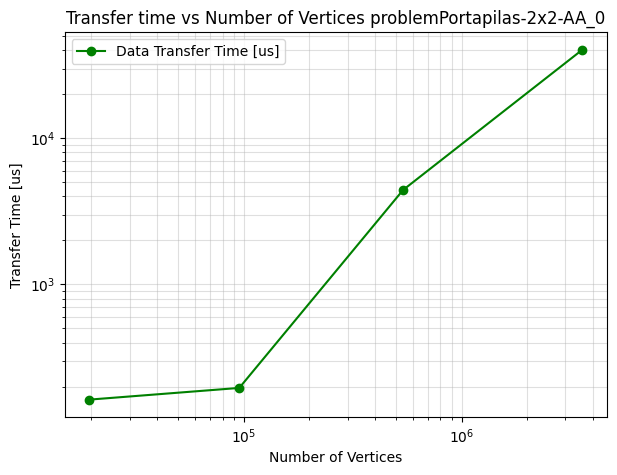

In [ ]:

tran_time = data['transfer_time_us'].values
n_vertices_arr = data['n_vertices'].values

plt.figure(figsize=(7, 5))
#plt.loglog(n_vertices_arr, runtime_arr, 'bo-', label='Solve Time [us]')
plt.loglog(n_vertices_arr, tran_time, 'go-', label='Data Transfer Time [us]')
ref_line_max = [tran_time[0] * (v / n_vertices_arr[0])**(1) for v in n_vertices_arr]
#plt.loglog(n_vertices_arr, ref_line_max, 'r--', label='O(1)')

plt.xlabel('Number of Vertices')
plt.ylabel('Transfer Time [us]')
plt.title(f"Transfer time vs Number of Vertices problem {base_problem_name[:-2]}")
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()
plt.show()

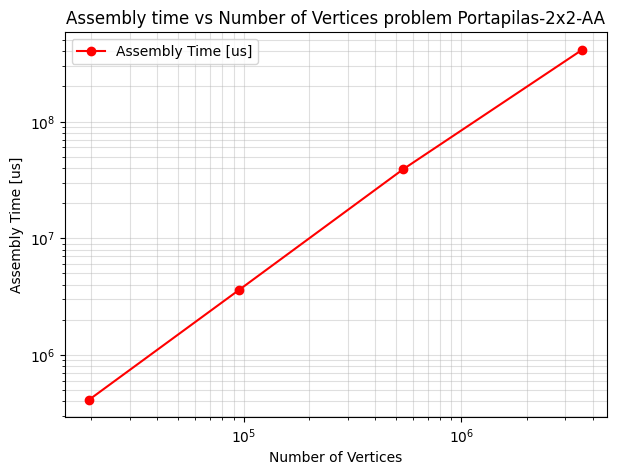

In [39]:

assemble_time = data['assemble_time_us'].values
n_vertices_arr = data['n_vertices'].values

plt.figure(figsize=(7, 5))
#plt.loglog(n_vertices_arr, runtime_arr, 'bo-', label='Solve Time [us]')
plt.loglog(n_vertices_arr, assemble_time, 'ro-', label='Assembly Time [us]')
ref_line_max = [assemble_time[0] * (v / n_vertices_arr[0])**(1) for v in n_vertices_arr]
#plt.loglog(n_vertices_arr, ref_line_max, 'r--', label='O(1)')

plt.xlabel('Number of Vertices')
plt.ylabel('Assembly Time [us]')
plt.title(f"Assembly time vs Number of Vertices problem {base_problem_name[:-2]}")
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()
plt.show()

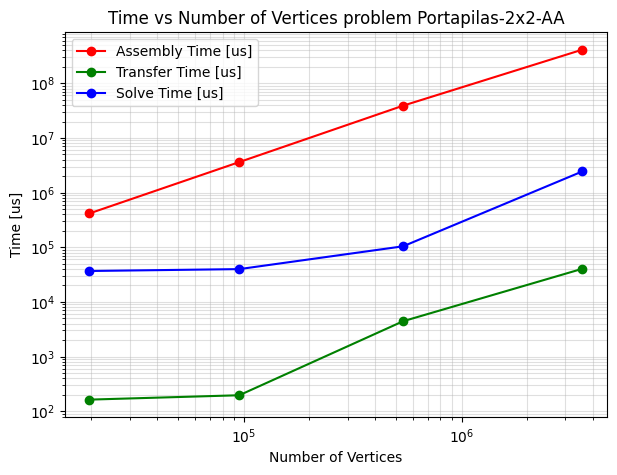

In [41]:

plt.figure(figsize=(7, 5))
#plt.loglog(n_vertices_arr, runtime_arr, 'bo-', label='Solve Time [us]')
plt.loglog(n_vertices_arr, assemble_time, 'ro-', label='Assembly Time [us]')
plt.loglog(n_vertices_arr, tran_time, 'go-', label='Transfer Time [us]')
plt.loglog(n_vertices_arr, runtime_arr, 'bo-', label='Solve Time [us]')
ref_line_max = [assemble_time[0] * (v / n_vertices_arr[0])**(1) for v in n_vertices_arr]
#plt.loglog(n_vertices_arr, ref_line_max, 'r--', label='O(1)')

plt.xlabel('Number of Vertices')
plt.ylabel('Time [us]')
plt.title(f"Time vs Number of Vertices problem {base_problem_name[:-2]}")
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()
plt.show()

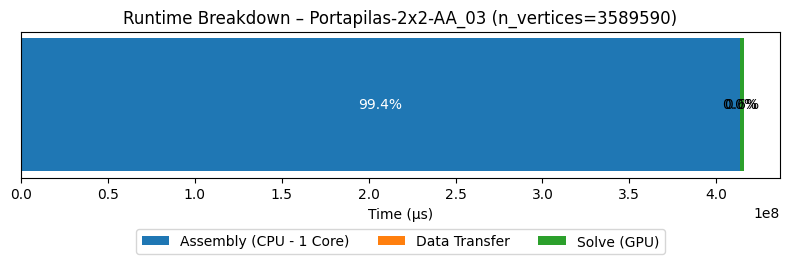

In [37]:
trans_problem = "Portapilas-2x2-AA_03"

row = data.loc[data['problem_name'] == trans_problem].iloc[0]

trans_problem_assemble_time = row['t_assem(us)']
trans_problem_transfer_time = row['transfer_time_us']
trans_problem_runtime = row['solve_time_us']
trans_problem_n_vertices = row['n_vertices']

times = np.array([trans_problem_assemble_time, trans_problem_transfer_time, trans_problem_runtime])
total_time = np.sum(times)
percentages = times / total_time * 100
labels = ['Assembly (CPU - 1 Core)', 'Data Transfer', 'Solve (GPU)']

fig, ax = plt.subplots(figsize=(8, 3))

left = 0
for time, pct, label in zip(times, percentages, labels):
    ax.barh(
        y=0,
        width=time,
        left=left,
        label=label
    )

    ax.text(
        left + time / 2,
        0,
        f"{pct:.1f}%",
        va="center",
        ha="center",
        fontsize=10,
        color="white" if pct > 10 else "black"
    )

    left += time

ax.set_yticks([])
ax.set_xlabel("Time (µs)")
ax.set_title(f"Runtime Breakdown – {trans_problem} (n_vertices={trans_problem_n_vertices})")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=3)

plt.tight_layout()
plt.show()
